# Extra tasks
The advanced extra tasks were made using Claude AI's help, to fully understand the functionalities. 
Further infromation about AIs usage will be mentioned later.

In [1]:
import sys, glob, warnings
warnings.filterwarnings("ignore")
sys.path.append("../../") # lets us import helper.py
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from helper import *
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

DATA_FILE = glob.glob("../../data/melbourne/*.csv")[0]
TARGET = "Price"
df = pd.read_csv(DATA_FILE)


df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce") # sale date: text - datetime
df["Postcode"] = df["Postcode"].astype("Int64").astype(str) # a code, not a quantity - text
LAT = next(c for c in df.columns if c.lower().startswith("lat"))# the Kaggle file spells it "Lattitude"
LON = next(c for c in df.columns if c.lower().startswith("long"))

num_cols, cat_cols = split_columns(df, TARGET)# feature lists WITHOUT the target (Date is excluded from both)
print(df.shape, "| numeric features:", len(num_cols), "| categorical features:", len(cat_cols))

(13580, 21) | numeric features: 11 | categorical features: 8


## 4a) Rare combinations

In [2]:
combo = df.groupby(["Type", "Regionname", "Method"]).size().sort_values()
print(f"{len(combo)} combinations occur; {int((combo <= 5).sum())} of them have 5 rows or fewer")
display(combo.head(10).to_frame("rows"))
print("Rooms >= 6 :", int((df["Rooms"] >= 6).sum()), "rows | Rooms == 1 and Type == 'h':", int(((df["Rooms"] == 1) & (df["Type"] == "h")).sum()))
try:
    from mlxtend.frequent_patterns import apriori
    basket = pd.get_dummies(df[["Type", "Regionname", "Method"]]).astype(bool)
    freq = apriori(basket, min_support=0.01, use_colnames=True); print("Apriori itemsets (support >= 1%):", len(freq)); display(freq.sort_values("support").head(8))
except ImportError:
    print("mlxtend not installed -> Apriori skipped (optional)")

86 combinations occur; 22 of them have 5 rows or fewer


rows
Type Regionname                 Method      
h    Eastern Victoria           SA         1
     Northern Victoria          PI         1
                                VB         1
                                SA         1
t    South-Eastern Metropolitan PI         1
     Northern Metropolitan      SA         1
u    South-Eastern Metropolitan PI         1
     Eastern Victoria           SP         1
     South-Eastern Metropolitan VB         1
t    Western Metropolitan       SA         2

Rooms >= 6 : 86 rows | Rooms == 1 and Type == 'h': 58
mlxtend not installed -> Apriori skipped (optional)


## 4c) Trends between support features

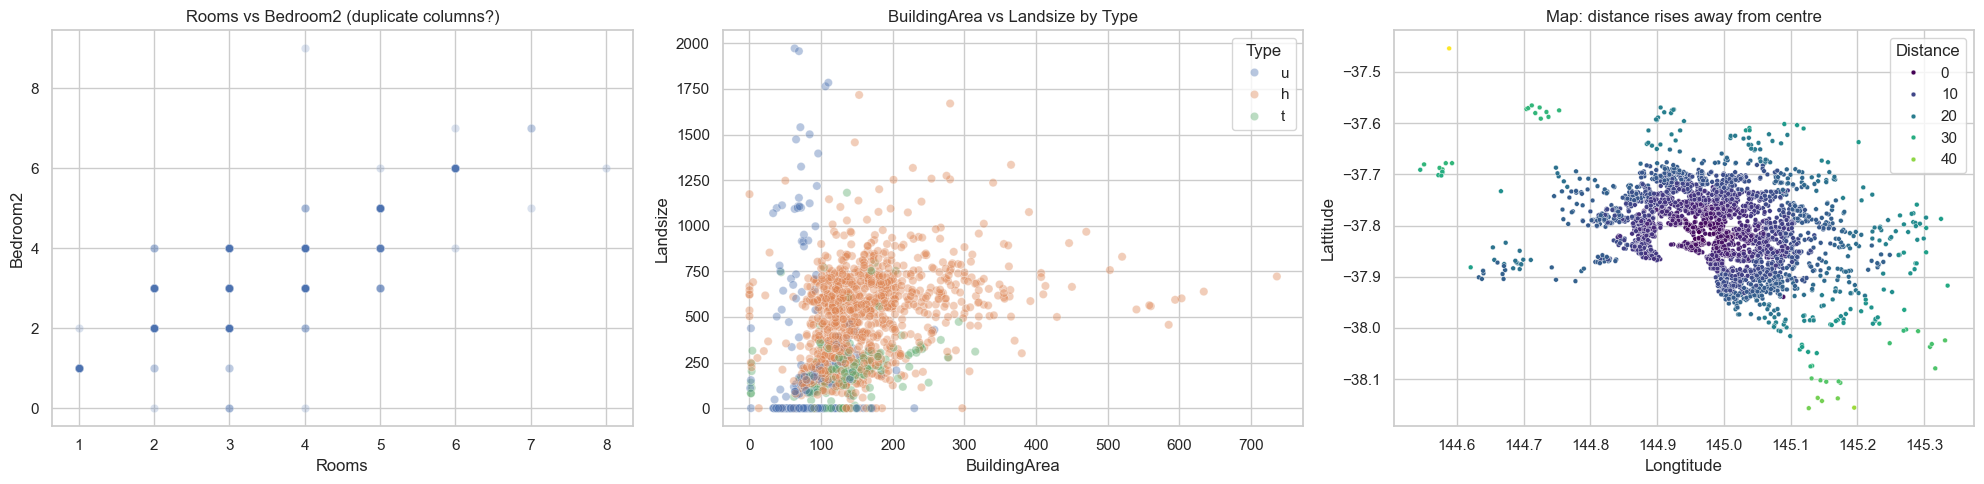

In [3]:
s = df.sample(min(3000, len(df)), random_state=3)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.scatterplot(data=s, x="Rooms", y="Bedroom2", alpha=.2, ax=axes[0]); axes[0].set_title("Rooms vs Bedroom2 (duplicate columns?)")
sns.scatterplot(data=s[(s["Landsize"] < 2000) & (s["BuildingArea"] < 1000)], x="BuildingArea", y="Landsize", hue="Type", alpha=.4, ax=axes[1]); axes[1].set_title("BuildingArea vs Landsize by Type")
sns.scatterplot(data=s, x=LON, y=LAT, hue="Distance", palette="viridis", s=12, ax=axes[2]); axes[2].set_title("Map: distance rises away from centre")
plt.tight_layout(); plt.show()

## 4d) Conventional EDA vs tools

In [4]:
checks = pd.DataFrame({
    "pandas result": [int(df.isna().sum().sum()), int(df.duplicated().sum()), round(df["BuildingArea"].isna().mean() * 100, 1),
                      round(df["YearBuilt"].isna().mean() * 100, 1), int((df["Landsize"] == 0).sum()), round(df[TARGET].skew(), 2),
                      df["Address"].nunique(), round(df[["Rooms", "Bedroom2"]].corr().iloc[0, 1], 3)],
    "ydata-profiling shows (fill in)": [""] * 8,
}, index=["total missing cells", "duplicate rows", "BuildingArea missing %", "YearBuilt missing %", "Landsize zeros", "Price skew", "unique Address", "corr Rooms~Bedroom2"])
display(checks)

,pandas result,ydata-profiling shows (fill in)
total missing cells,13256.000,
duplicate rows,0.000,
BuildingArea missing %,47.500,
YearBuilt missing %,39.600,
Landsize zeros,1939.000,
Price skew,2.240,
unique Address,13378.000,
corr Rooms~Bedroom2,0.944,


## 4e) Non-linear (polynomial) trends

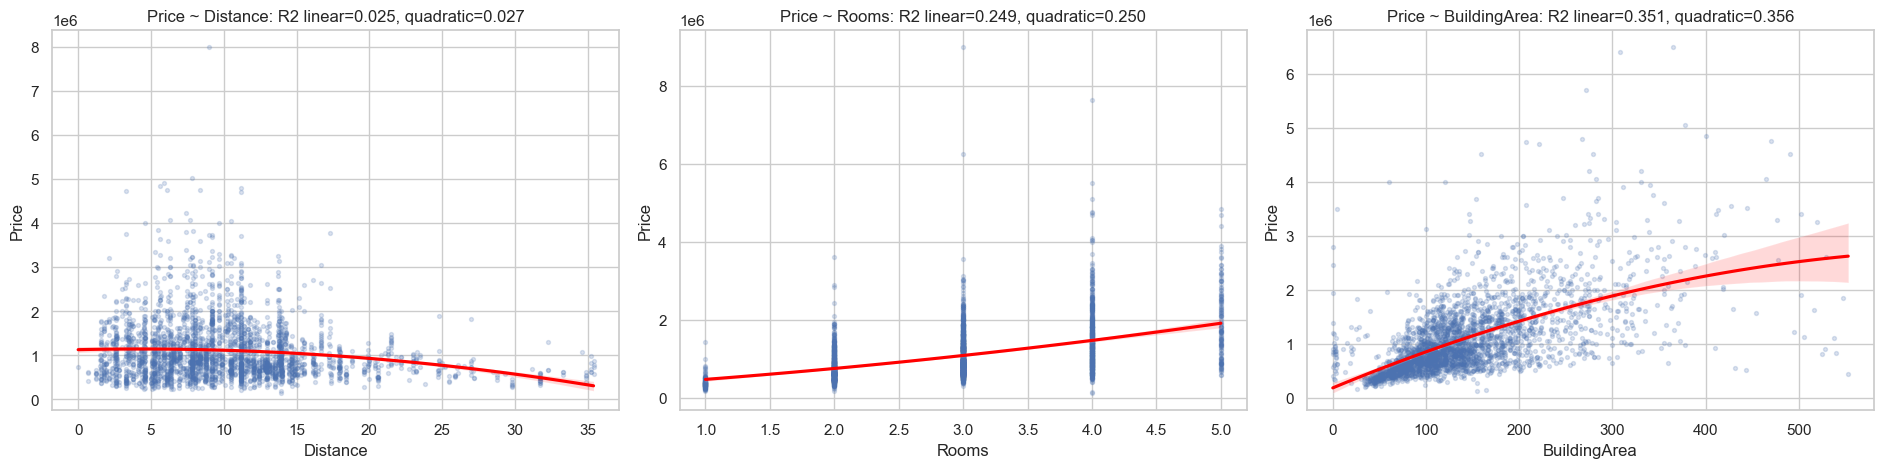

In [5]:
pairs = [("Distance", TARGET), ("Rooms", TARGET), ("BuildingArea", TARGET)]
s2 = df[(df["BuildingArea"] < 1000) | df["BuildingArea"].isna()].sample(min(4000, len(df)), random_state=5)
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, (x, y_) in zip(axes, pairs):
    dd = df[[x, y_]].dropna(); dd = dd[dd[x] < dd[x].quantile(.995)]
    sns.regplot(data=dd.sample(min(3000, len(dd)), random_state=1), x=x, y=y_, order=2, scatter_kws={"alpha": .2, "s": 8}, line_kws={"color": "red"}, ax=ax)
    r2 = {}
    for deg in (1, 2):
        p = np.polyfit(dd[x], dd[y_], deg); r2[deg] = 1 - ((dd[y_] - np.polyval(p, dd[x])) ** 2).sum() / ((dd[y_] - dd[y_].mean()) ** 2).sum()
    ax.set_title(f"{y_} ~ {x}: R2 linear={r2[1]:.3f}, quadratic={r2[2]:.3f}")
plt.tight_layout(); plt.show()